# Introducing Scikit-learn

There are several Python libraries which provide solid implementations of a range of machine learning algorithms. One of the best known is scikit-learn, a package which provides efficient versions of a large number of common algorithms. 

Scikit-learn is characterized by a clean, uniform, and streamlined API, as well as by very useful and complete online documentation. A benefit of this uniformity is that once you under‐ stand the basic use and syntax of scikit-learn for one type of model, switching to a new model or algorithm is very straightforward.

This section provides an overview of the API of scikit-learn; a solid understanding of these API elements will form the foundation for understanding the deeper practical discussion of machine learning algorithms and approaches.

## Machine Learning Settings

Machine learning algorithms come in two different "flavours":

- **Supervised Learning**
    - _Classification_
    - _Regression_
    
    
- **Unsupervised Learning**
    - _Dimensionality Reduction_
    - _Clustering_

## Scikit-learn Cheat Sheet

<img src="images/scikit-learn-cheatsheet.png" width="100%" />

## 1. Representation and Visualization of Data

Data in scikit-learn, with very few exceptions, is assumed to be stored as a
**two-dimensional array**, of size `[n_samples, n_features]`. 
This array is usually referrred as the **feature matrix**.

There is also the **label vector**, of size `n_samples`, containing the list of labels
for each samples (_Note_: **ONLY** in the Supervised Learning settings)

$$
{\rm feature~matrix:~~~} {\bf X}~=~\left[
\begin{matrix}
x_{11} & x_{12} & \cdots & x_{1D}\\
x_{21} & x_{22} & \cdots & x_{2D}\\
x_{31} & x_{32} & \cdots & x_{3D}\\
\vdots & \vdots & \ddots & \vdots\\
\vdots & \vdots & \ddots & \vdots\\
x_{N1} & x_{N2} & \cdots & x_{ND}\\
\end{matrix}
\right]
$$

$$
{\rm label~vector:~~~} {\bf y}~=~ [y_1, y_2, y_3, \cdots y_N]
$$

Here there are $N$ samples and $D$ features.

- $N$ (`n_samples`):   The number of samples: each sample is an item to process (e.g. classify).
  A sample can be a document, a picture, a sound, a video, an astronomical object,
  a row in database or CSV file,
  or whatever you can describe with a fixed set of quantitative traits.
- $D$ (`n_features`):  The number of features or distinct traits that can be used to describe each
  item in a quantitative manner.  Features are generally real-valued, but may be boolean or
  discrete-valued in some cases.

The number of features must be fixed in advance. 

However it can be very high dimensional
(e.g. millions of features) with most of them being zeros for a given sample. This is a case
where `scipy.sparse` matrices can be useful, in that they are
much more memory-efficient than numpy arrays.

Each sample (data point) is a row in the data array, and each feature is a column.

### Simple Example: Iris Dataset

As an example of a simple dataset, we're going to take a look at the iris data stored by scikit-learn.
The data consists of measurements of three different species of irises.  

There are three species of iris in the dataset:

<style type="text/css">
    ul#flowers li {
        display:inline !important;
    }
</style>

<ul id="flowers">
    <li>
        Iris Setosa
        <img src="images/iris_setosa.jpg" width="25%">
    </li>
    <li>
        Iris Versicolor
        <img src="images/iris_versicolor.jpg" width="25%">
    </li>
    <li>
        Iris Virginica
        <img src="images/iris_virginica.jpg" width="25%">
    </li>
</ul>

### Quick Question:

**If we want to design an algorithm to recognize iris species, what might the data be?**

Remember: we need a 2D array of size `[n_samples x n_features]`.

- What would the `n_samples` refer to?

- What might the `n_features` refer to?

Remember that there must be a **fixed** number of features for each sample, and feature
number ``i`` must be a similar kind of quantity for each sample.

## Ex 1.1

Load the iris dataset from `sklearn` and print out description.

#### Hint: Inspect attributes of the `sklearn.datasets.base.Bunch` object

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

## Ex 1.2

Save `iris` data into a numpy array `X` and print out attributes along with corresponding `targets`.


In [2]:
import numpy as np

X = iris.data
y = iris.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFirst 5 samples:")
print(X[:5])
print("\nCorresponding targets:")
print(y[:5])

Feature matrix shape: (150, 4)
Target vector shape: (150,)

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Corresponding targets:
[0 0 0 0 0]


## Ex 1.3

Plot `iris` data using a scatter plot

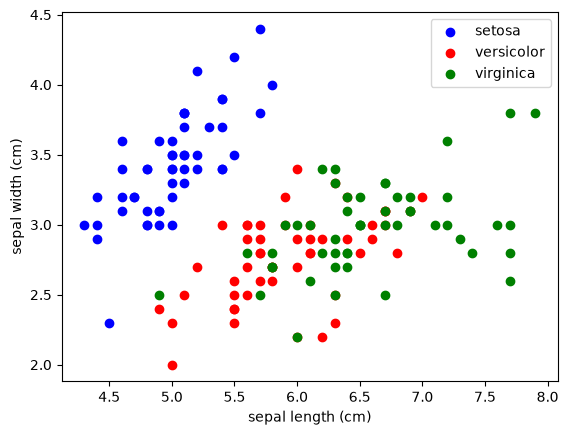

In [3]:
import matplotlib.pyplot as plt

x_index = 0
y_index = 1

colors = ['blue', 'red', 'green']
for i in range(len(colors)):
    xs = X[y == i, x_index]
    ys = X[y == i, y_index]
    plt.scatter(xs, ys, c=colors[i], label=iris.target_names[i])

plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])
plt.legend()
plt.show()

## Ex 1.3.1

**Change** `x_index` **and** `y_index` **in the above script
and find a combination of two parameters
which maximally separate the three classes.**

This exercise is a preview of **dimensionality reduction**

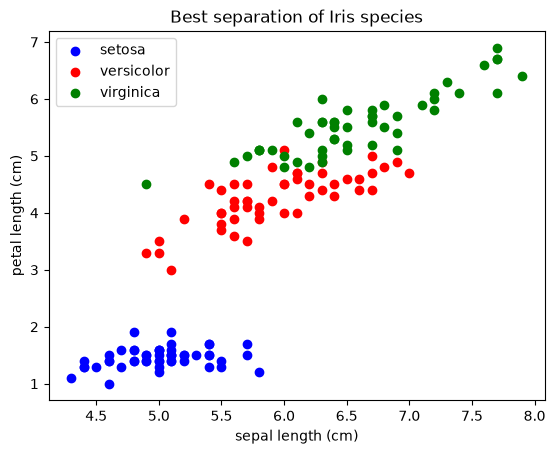

In [4]:
# Try different combinations to find the best separation
# Let's try sepal length vs petal length
x_index = 0  # sepal length
y_index = 2  # petal length

colors = ['blue', 'red', 'green']
for i in range(len(colors)):
    xs = X[y == i, x_index]
    ys = X[y == i, y_index]
    plt.scatter(xs, ys, c=colors[i], label=iris.target_names[i])

plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])
plt.legend()
plt.title("Best separation of Iris species")
plt.show()

## Ex 1.4

Loads the `digits` data and print some data extracted from the dataset.

#### Hint: See `digits.data` and `digits.images`. Do you see any difference?

In [5]:
from sklearn.datasets import load_digits

digits = load_digits()

print("Shape of digits.data:", digits.data.shape)
print("Shape of digits.images:", digits.images.shape)
print("\nFirst digit data:")
print(digits.data[0])
print("\nFirst digit as image:")
print(digits.images[0])
print("\nTarget:", digits.target[0])

Shape of digits.data: (1797, 64)
Shape of digits.images: (1797, 8, 8)

First digit data:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]

First digit as image:
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]

Target: 0


## 2. Supervised Learning: Classification

<img src="images/supervised_workflow.svg" width="80%">

## Ex 2.1

As classification is a supervised task, and we are interested in how well the model generalizes, we split our data into a training set,
to built the model from, and a test-set, to evaluate how well our model performs on new data. 
The ``train_test_split`` function form the ``cross_validation`` module does that for us, by randomly splitting of 25% of the data for testing.

<img src="images/train_test_split.svg" width="80%">

Load data from the IRIS dataset and split training and test sets

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, 
                                                      test_size=0.25, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)

Training set size: (112, 4)
Test set size: (38, 4)
Training labels: (112,)
Test labels: (38,)


## Ex 2.2 

`fit` a `LogisticRegression` model to classify on training data

#### Hint: Suggestions in the text !-)

In [7]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

print("Model fitted successfully!")
print("Accuracy on training set:", clf.score(X_train, y_train))

Model fitted successfully!
Accuracy on training set: 0.9642857142857143


## Ex 2.3

Make Predictions on the remaining test set data

#### Hint: Leverage on previsou `train-test` split

In [8]:
y_pred = clf.predict(X_test)

print("Predictions:", y_pred)
print("True labels:  ", y_test)
print("Accuracy on test set:", clf.score(X_test, y_test))

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
True labels:   [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
Accuracy on test set: 1.0


## Ex 2.4

Try a new Machine Learning model: `KNeighborsClassifier`

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNeighborsClassifier fitted successfully!")
print("Accuracy on training set:", knn.score(X_train, y_train))

KNeighborsClassifier fitted successfully!
Accuracy on training set: 0.9642857142857143


## Ex 2.5

Calculate the accuracy `score` on test data with the `KNeighborsClassifier`

#### Hint: Clues in the text (as usual)

In [10]:
y_pred_knn = knn.predict(X_test)

print("Predictions:", y_pred_knn)
print("Accuracy on test set:", knn.score(X_test, y_test))

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
Accuracy on test set: 1.0


# 3. Regression

In regression we try to predict a continuous output variable. 

This can be most easily visualized in one dimension.

## Linear Regression

One of the simplest models again is a linear one, that simply tries to predict the data as lying on a line. One way to find such a line is LinearRegression (also known as ordinary least squares).
The interface for LinearRegression is exactly the same as for the classifiers before, only that ``y`` now contains float values, instead of classes.

## Ex 3.1

Generate `X` data and `y` target picking from the `sin` function plus some random noise (i.e. `np.random.uniform`)

In [11]:
X_reg = np.sort(np.random.uniform(0, 2 * np.pi, 100))
y_reg = np.sin(X_reg) + np.random.uniform(-0.3, 0.3, size=X_reg.shape)

X_reg = X_reg.reshape(-1, 1)  # sklearn expects a 2D feature matrix

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (100, 1)
y shape: (100,)


## Ex 3.2

Fit a linear regression model using `sklearn.linear_model.LinearRegression`

In [12]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_reg, y_reg)

print("Linear regression fitted!")
print("Coefficient:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)

Linear regression fitted!
Coefficient: [-0.29031483]
Intercept: 0.8196969373438516


## Ex 3.3

Plot original data and predicted data

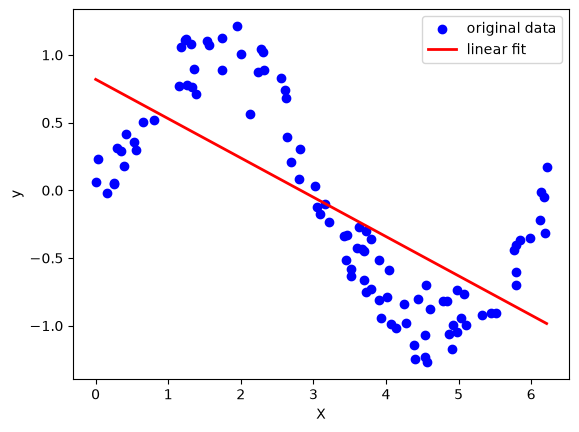

In [13]:
y_pred_reg = lin_reg.predict(X_reg)

plt.scatter(X_reg, y_reg, color="blue", label="original data")
plt.plot(X_reg, y_pred_reg, color="red", linewidth=2, label="linear fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Ex 3.4

Try to think of a better model to fit. Fit and plot the data, as in previous exercises.

#### Hint: `KNeighborsRegression` model, maybe?

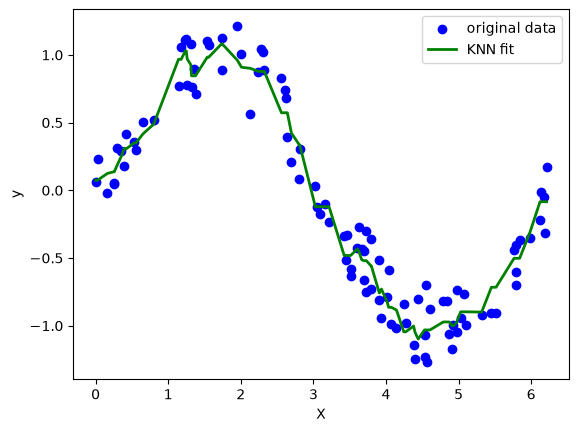

In [14]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_reg, y_reg)

y_pred_knn_reg = knn_reg.predict(X_reg)

plt.scatter(X_reg, y_reg, color="blue", label="original data")
plt.plot(X_reg, y_pred_knn_reg, color="green", linewidth=2, label="KNN fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# 4. Unsupervised Learning

<img src="images/unsupervised_workflow.svg" width="80%">

## Clustering

Clustering is the task of gathering samples into groups of similar
samples according to some predefined similarity or dissimilarity
measure (such as the Euclidean distance).
In this section we will explore a basic clustering task on some synthetic and real datasets.

Here are some common applications of clustering algorithms:

- Compression, in a data reduction sens
- Can be used as a preprocessing step for recommender systems
- Similarly:
   - grouping related web news (e.g. Google News) and web search results
   - grouping related stock quotes for investment portfolio management
   - building customer profiles for market analysis
- Building a code book of prototype samples for unsupervised feature extraction



## Ex 4.1

Generate some random data, organised in blobs (i.e. artifically created agglomerations of points in the space)

#### Hint: Take a look at `make_blobs`

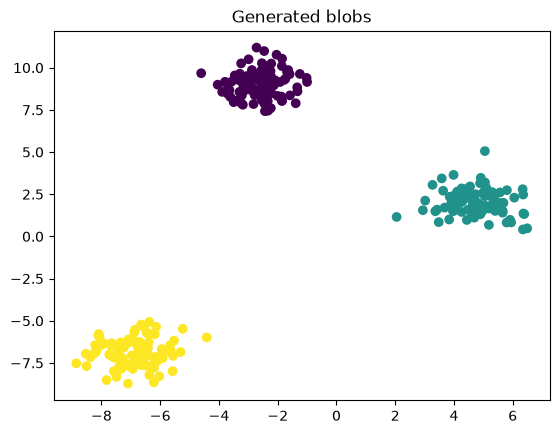

In [15]:
from sklearn.datasets import make_blobs

X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap="viridis")
plt.title("Generated blobs")
plt.show()

## Ex 4.2

Now we will use one of the simplest clustering algorithms, K-means.
This is an iterative algorithm which searches for three cluster
centers such that the distance from each point to its cluster is
minimized.


#### Hint: See `sklearn.cluster.KMeans`

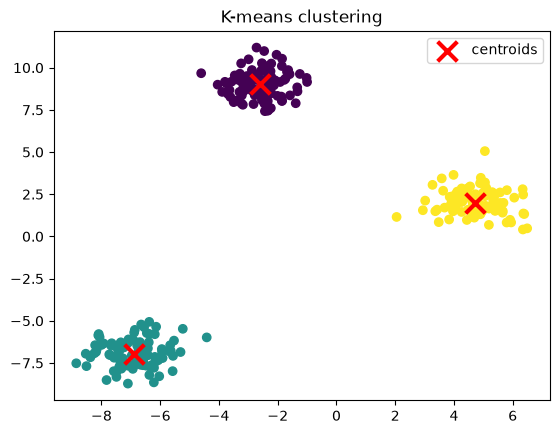

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_blobs)

plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=kmeans.labels_, cmap="viridis")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="x", s=200, linewidths=3, label="centroids")
plt.title("K-means clustering")
plt.legend()
plt.show()